# Chapter 10 - Short Rate Models with Stochastic Volatility
# 1. Introduction

This chapter extends the Hull-White short-rate model by allowing
the volatility of the short rate itself to evolve randomly through time.

Chapter 09:

$$
dr_t =
[\theta(t)-ar_t]dt
+
\sigma dW_t
$$

assumes constant volatility.

In practice, interest-rate volatility changes through time.

This chapter introduces:

$$
dr_t =
[\theta(t)-ar_t]dt
+
\sqrt{v_t}dW_t^r
$$

with:

$$
dv_t =
\kappa(v_{\infty}-v_t)dt
+
\eta\sqrt{v_t}dW_t^v
$$

and:

$$
corr(dW_t^r,dW_t^v)=\rho
$$

This framework combines:

- Hull-White mean reversion
- CIR stochastic variance
- Monte Carlo pricing

and serves as a bridge toward modern stochastic-volatility interest-rate models.

---

# 2. Import Libraries

In [30]:
import sys

sys.path.append("../python")
sys.path.append("../../09_hull_white_short_rate_model/python")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from market_data import load_curve_data

from hull_white_model import HullWhiteModel

from bond_pricing import (
    zero_coupon_bond_price
)

from option_pricing import (
    price_zero_coupon_bond_option
)

from stochastic_vol_model import (
    StochasticVolShortRateModel
)

from stochastic_vol_simulation import (
    simulate_stochastic_vol_paths
)

from pricing import (
    monte_carlo_zero_coupon_bond_price,
    monte_carlo_bond_option_price,
    estimate_terminal_statistics
)

from scenario_analysis import (
    run_eta_scenarios,
    run_rho_scenarios,
    run_kappa_scenarios,
    plot_eta_scenario_summary,
    plot_rho_scenario_summary,
    plot_kappa_scenario_summary
)

from plotting import *

from diagnostics import *

---
# 3. Load Curve Data

In [2]:
curve = load_curve_data(
    "../../09_hull_white_short_rate_model/data/usd_zero_curve.csv"
)

curve

---
# 4. Hull-White Baseline Model

In [3]:
hw_model = HullWhiteModel(
    mean_reversion=0.05,
    volatility=0.01,
    curve=curve
)

hw_model

In [4]:
r0 = hw_model.instantaneous_forward_rate(
    1e-6
)

print(
    "Initial short rate:",
    r0
)

Initial short rate: 0.02000000000000102


---
# 5. Stochastic Volatility Extension

We now replace the constant volatility:

$$
\sigma
$$

with a stochastic variance process:

$$
v_t
$$

and:

$$
\sigma_t =
\sqrt{v_t}
$$

In [5]:
sv_model = StochasticVolShortRateModel(
    base_hw_model=hw_model,
    kappa=1.0,
    v_bar=0.0001,
    eta=0.20,
    rho=-0.30
)

sv_model

---
# 6. Monte Carlo Simulation

In [6]:
times, rate_paths, variance_paths = (
    simulate_stochastic_vol_paths(
        model=sv_model,
        r0=r0,
        v0=0.0001,
        maturity=10.0,
        n_steps=240,
        n_paths=5000,
        seed=42
    )
)

In [7]:
rate_paths.shape

(5000, 241)

In [8]:
variance_paths.shape

(5000, 241)

In [9]:
# 7. Short-Rate Dynamics

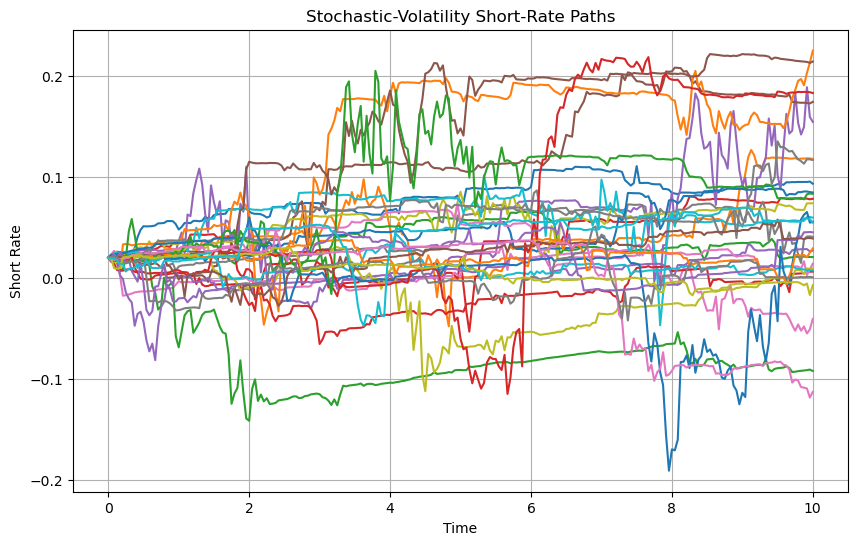

In [10]:
plot_rate_paths(
    times,
    rate_paths
)

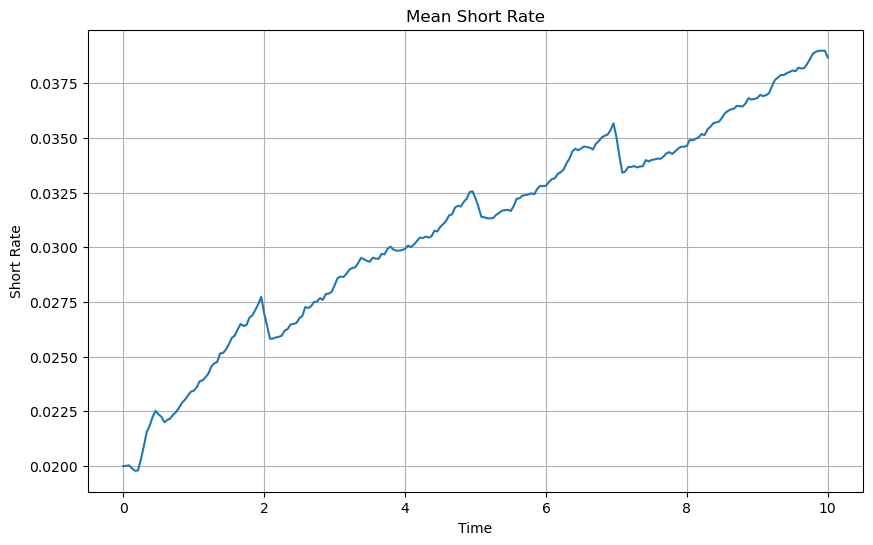

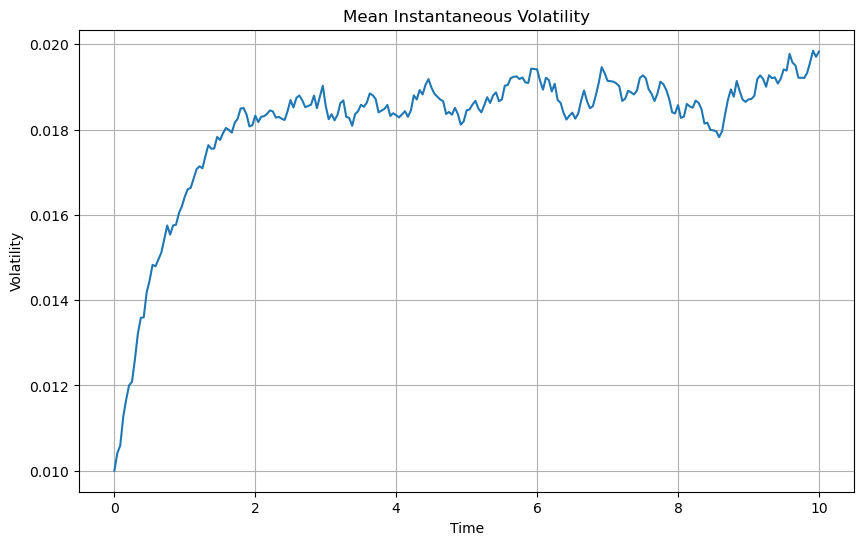

In [11]:
plot_mean_rate_and_vol(
    times,
    rate_paths,
    variance_paths
)

The mean short rate remains anchored by the Hull-White
mean-reversion mechanism.

The volatility evolves stochastically through time
and can deviate significantly from its long-run level.

---

# 7 Variance Dynamics

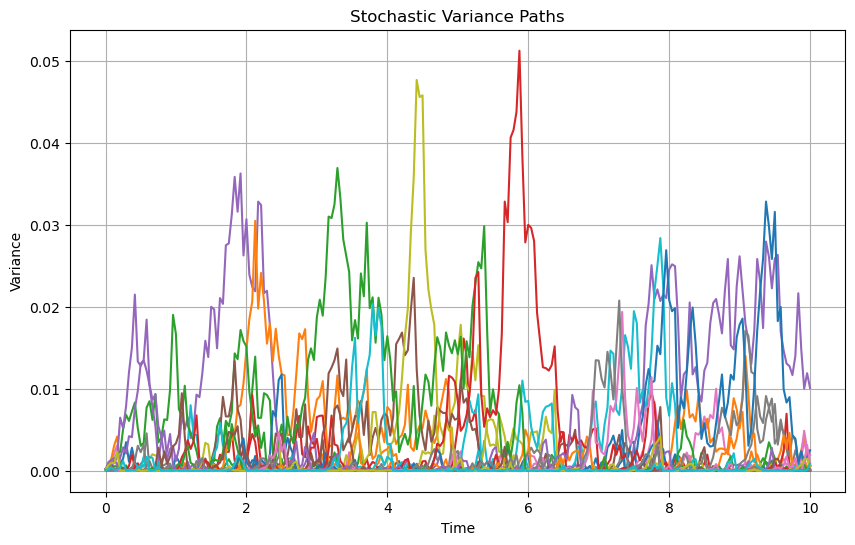

In [12]:
plot_variance_paths(
    times,
    variance_paths
)

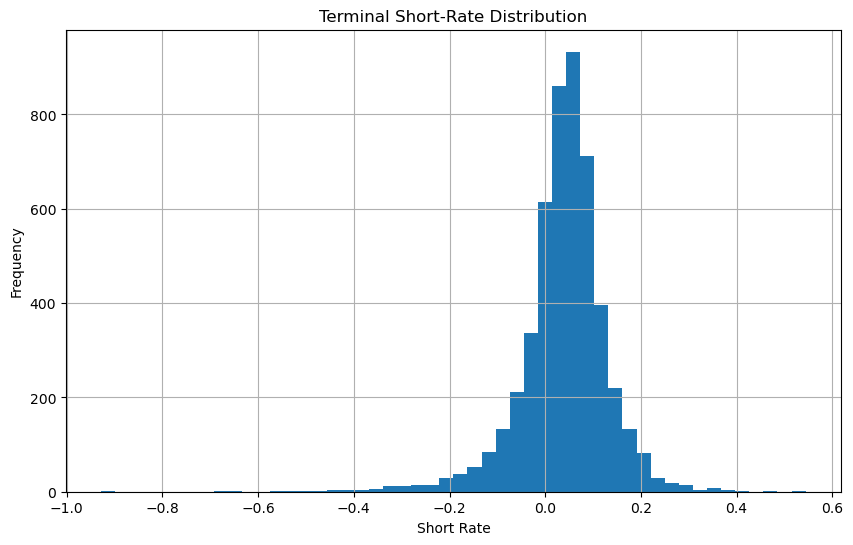

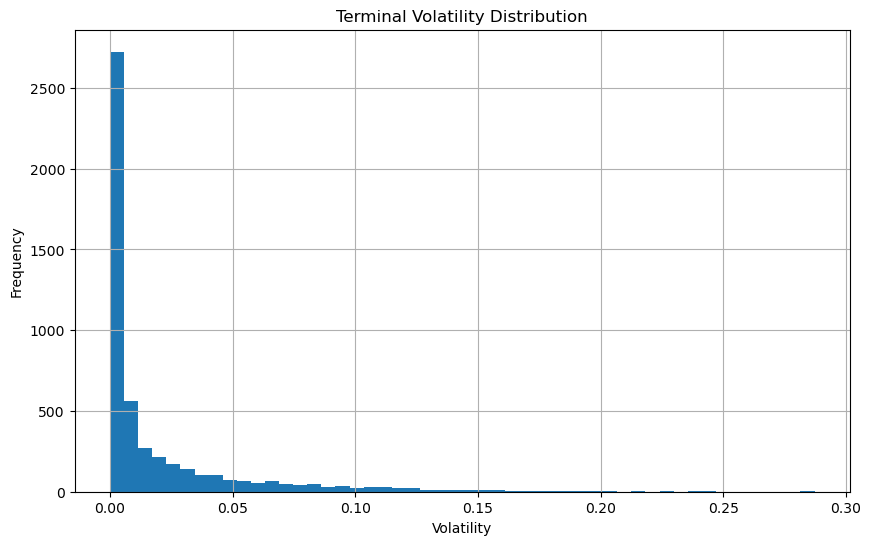

In [13]:
plot_terminal_distributions(
    rate_paths,
    variance_paths
)

The CIR variance process ensures positivity:

$$
v_t \ge 0
$$

which avoids the negative variance problem often encountered
with Gaussian volatility models.

---

# 8. Terminal Statistics

In [14]:
stats = estimate_terminal_statistics(
    rate_paths,
    variance_paths
)

stats

{'rate_mean': 0.03867417995568584,
 'rate_std': 0.09273935666976271,
 'variance_mean': 0.0016127571548070953,
 'variance_std': 0.005329114124252362,
 'vol_mean': 0.019827136503164904}

In [15]:
summarize_stochastic_vol_paths(
    rate_paths,
    variance_paths
)

Stochastic-Vol Short-Rate Path Summary
Final rate mean     : 0.038674
Final rate std      : 0.092739
Final rate min      : -0.928251
Final rate max      : 0.544318

Final variance mean : 0.001613
Final variance std  : 0.005329
Final vol mean      : 0.019827
Final vol std       : 0.034923


---
# 9. Zero-Coupon Bond Pricing

Unlike Chapter 09, there is generally no closed-form
discount-bond pricing formula once volatility becomes stochastic.

Monte Carlo becomes the primary valuation tool.

In [16]:
bond_price_mc = (
    monte_carlo_zero_coupon_bond_price(
        times,
        rate_paths,
        maturity=5.0
    )
)

bond_price_mc

0.8921473016412481

In [17]:
market_df = curve.discount_factor(
    5.0
)

print("Market DF:", market_df)
print("MC DF:", bond_price_mc)

Market DF: 0.8737159116880344
MC DF: 0.8921473016412481


---
# 10. Bond Option Pricing

The constant-volatility Hull-White model and the stochastic-volatility
extension can produce materially different option values.

This difference reflects volatility uncertainty,
which is ignored by the constant-volatility framework.

In [18]:
option_price_sv = (
    monte_carlo_bond_option_price(
        times=times,
        rate_paths=rate_paths,
        option_expiry=2.0,
        bond_maturity=5.0,
        strike=0.90,
        option_type="call"
    )
)

option_price_sv

0.06385597685409466

In [20]:
option_price_hw = (
    price_zero_coupon_bond_option(
        model=hw_model,
        option_expiry=2.0,
        bond_maturity=5.0,
        strike=0.90,
        option_type="call"
    )
)

option_price_hw

np.float64(0.022423330244143336)

In [21]:
compare_option_prices(
    option_price_hw,
    option_price_sv
)

Bond Option Price Comparison
Constant-vol HW price  : 0.02242333
Stochastic-vol price   : 0.06385598
Difference             : 0.04143265


---
# 11. Constant Volatility vs Stochastic Volatility

In [22]:
from hull_white_simulation import (
    simulate_short_rate_paths
)

times_hw, hw_paths = (
    simulate_short_rate_paths(
        model=hw_model,
        r0=r0,
        maturity=10.0,
        n_steps=240,
        n_paths=5000,
        seed=42
    )
)

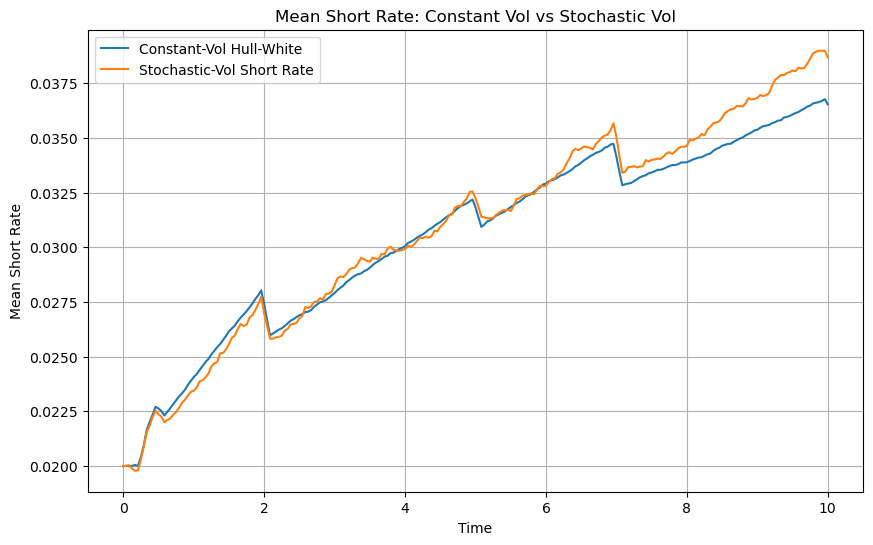

In [24]:
plot_constant_vs_stochastic_vol_rates(
    times,
    hw_paths,
    rate_paths
)

The average short-rate paths may appear similar because
both models share the same mean-reversion structure.

However, the stochastic-volatility model produces a much richer
distribution of future interest-rate outcomes.

---

# 12. Scenario Analysis Instead of Calibration

In Chapter 09, calibration was meaningful because the Hull-White model has a clear market-calibration role.

In this chapter, however, the main objective is different.

The stochastic-volatility short-rate model is used to study how volatility uncertainty changes:

- short-rate distributions
- zero-coupon bond prices
- bond option prices
- tail risk

Therefore, instead of calibrating to synthetic market prices, we run scenario analysis.

This is more informative for Chapter 10 because it directly shows how the stochastic-volatility parameters affect pricing and risk.

## 12.1 Vol-of-Vol Scenario: Changing eta

The parameter $\eta$ controls volatility-of-volatility.

A larger $\eta$ means the variance process becomes more volatile.

We test:

```text
eta = 0.05, 0.10, 0.20, 0.40, 0.80
```

and examine how bond option prices and terminal rate dispersion respond.

In [31]:
# ============================================================
# Cell — Eta Scenario Analysis
# ============================================================

eta_values = [
    0.05,
    0.10,
    0.20,
    0.40,
    0.80
]

eta_df = run_eta_scenarios(
    base_hw_model=hw_model,
    r0=r0,
    eta_values=eta_values,
    kappa=1.0,
    v_bar=0.0001,
    rho=-0.30,
    maturity=10.0,
    n_steps=240,
    n_paths=5000,
    bond_maturity=5.0,
    option_expiry=2.0,
    option_bond_maturity=5.0,
    option_strike=0.90,
    seed=42
)

eta_df

,kappa,v_bar,eta,rho,bond_price,bond_option_price,terminal_rate_mean,terminal_rate_std,terminal_rate_5pct,terminal_rate_95pct,terminal_vol_mean,terminal_vol_std
0,1.0,0.0001,0.05,-0.3,0.876257,0.028966,0.037849,0.035004,-0.021254,0.089428,0.009658,0.011394
1,1.0,0.0001,0.10,-0.3,0.880213,0.039396,0.037992,0.054521,-0.052984,0.117821,0.013022,0.019379
2,1.0,0.0001,0.20,-0.3,0.892147,0.063856,0.038674,0.092739,-0.110800,0.171082,0.019827,0.034923
3,1.0,0.0001,0.40,-0.3,0.953992,0.145845,0.039067,0.165963,-0.224728,0.266951,0.032288,0.064024
4,1.0,0.0001,0.80,-0.3,2.702406,1.921588,0.040405,0.303045,-0.444317,0.446990,0.055004,0.120144


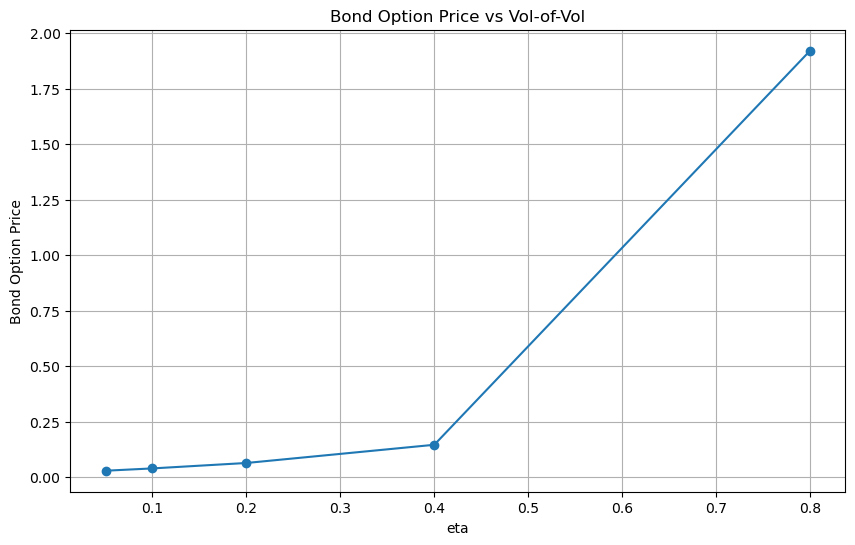

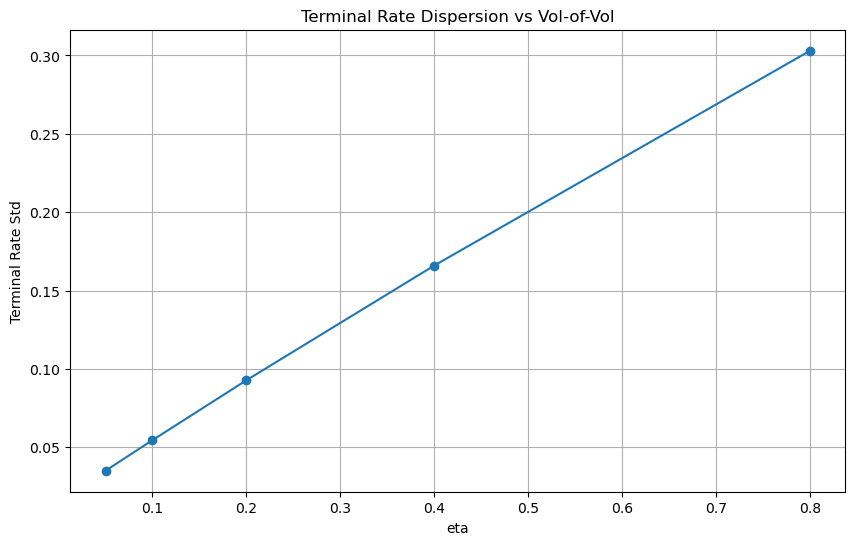

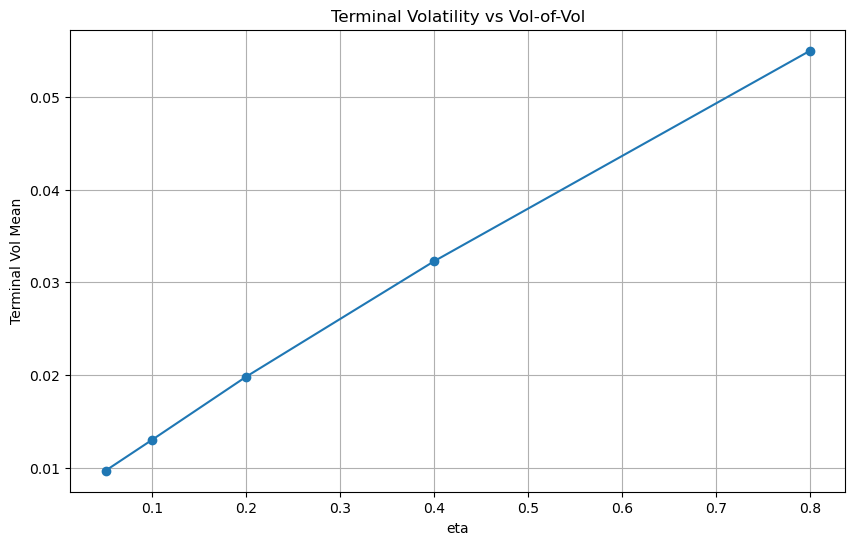

In [33]:
# ============================================================
# Cell — Plot Eta Scenario Results
# ============================================================

plot_eta_scenario_summary(
    eta_df
)

### Interpretation

As $\eta$ increases, volatility itself becomes more uncertain.

This typically increases the dispersion of future short rates and can increase option values because options benefit from greater uncertainty.

However, the effect is not always perfectly monotonic because:

- rate-vol correlation also matters
- variance is mean-reverting
- bond option payoffs are nonlinear
- discounting is path-dependent

## 12.2 Rate-Vol Correlation Scenario: Changing rho

The parameter $\rho$ controls the correlation between short-rate shocks and volatility shocks.

Negative $\rho$ means that downward rate (upward bond price) moves tend to be associated with higher volatility - this is a favourable situation, so the bond option price under negative $\rho$ is usually higher than that under positive $\rho$.

Positive $\rho$ means that upward rate (downward bond price) moves tend to be associated with higher volatility.

This can materially affect the distribution of rates and bond option prices.

In [34]:
# ============================================================
# Cell — Rho Scenario Analysis
# ============================================================

rho_values = [
    -0.80,
    -0.50,
    -0.30,
    0.00,
    0.30,
    0.50
]

rho_df = run_rho_scenarios(
    base_hw_model=hw_model,
    r0=r0,
    rho_values=rho_values,
    kappa=1.0,
    v_bar=0.0001,
    eta=0.20,
    maturity=10.0,
    n_steps=240,
    n_paths=5000,
    bond_maturity=5.0,
    option_expiry=2.0,
    option_bond_maturity=5.0,
    option_strike=0.90,
    seed=42
)

rho_df

,kappa,v_bar,eta,rho,bond_price,bond_option_price,terminal_rate_mean,terminal_rate_std,terminal_rate_5pct,terminal_rate_95pct,terminal_vol_mean,terminal_vol_std
0,1.0,0.0001,0.2,-0.8,0.891869,0.061042,0.038572,0.094155,-0.128175,0.127493,0.019272,0.034403
1,1.0,0.0001,0.2,-0.5,0.891261,0.062520,0.039254,0.091922,-0.118196,0.153028,0.019582,0.034433
2,1.0,0.0001,0.2,-0.3,0.892147,0.063856,0.038674,0.092739,-0.110800,0.171082,0.019827,0.034923
3,1.0,0.0001,0.2,0.0,0.891696,0.063368,0.038170,0.094121,-0.104385,0.187820,0.019668,0.035006
4,1.0,0.0001,0.2,0.3,0.891270,0.062465,0.037762,0.094139,-0.093031,0.204473,0.020069,0.036114
5,1.0,0.0001,0.2,0.5,0.890253,0.059972,0.037432,0.093779,-0.077316,0.203929,0.020325,0.036288


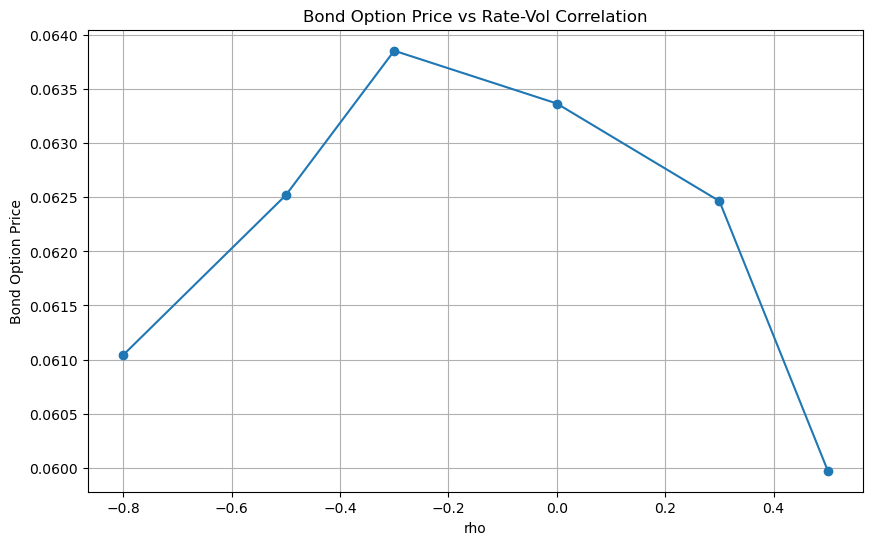

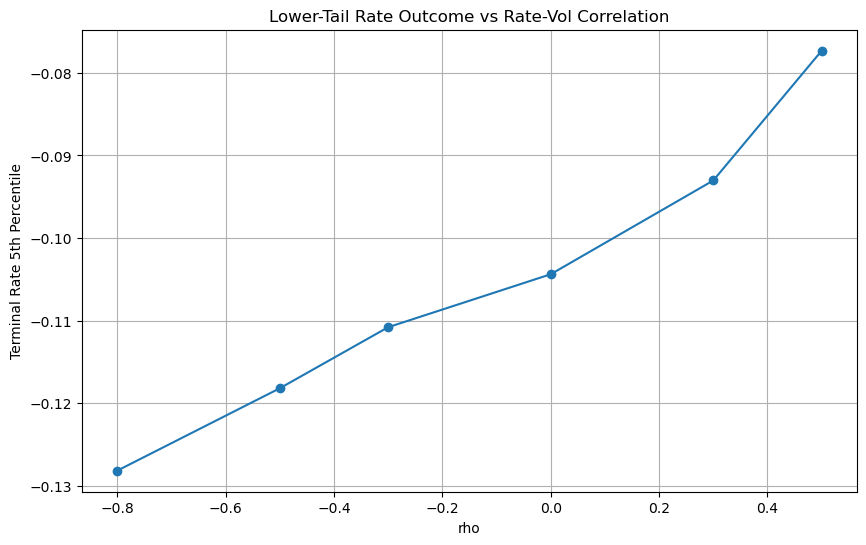

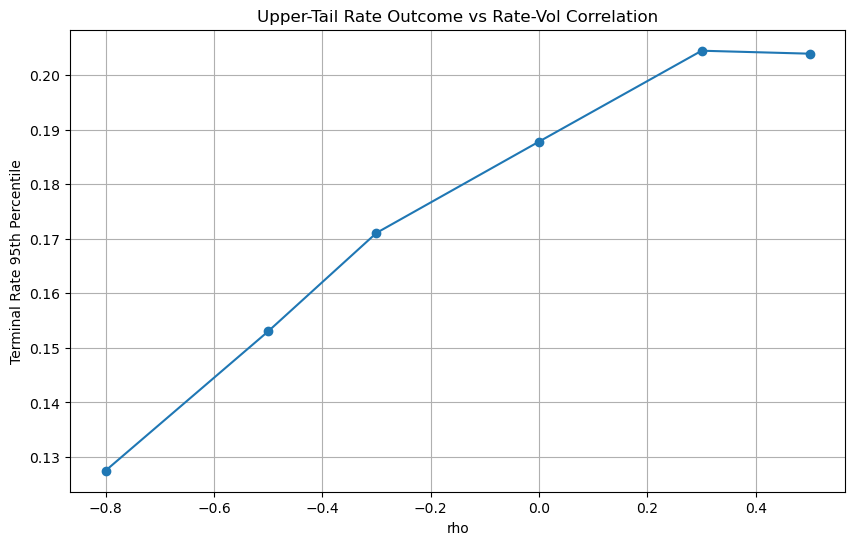

In [35]:
# ============================================================
# Cell — Plot Rho Scenario Results
# ============================================================

plot_rho_scenario_summary(
    rho_df
)

### Interpretation

Correlation changes the joint behaviour of rate and volatility shocks.

For rates products, this matters because the payoff depends not only on the level of rates, but also on how volatility evolves when rates move.

This is one of the key motivations for using stochastic-volatility models instead of constant-volatility Hull-White.

## 12.3 Variance Mean-Reversion Scenario: Changing kappa

The parameter $\kappa$ controls how quickly variance mean-reverts toward its long-run level.

Low $\kappa$:

```text
volatility shocks persist longer
```

High $\kappa$:

```text
volatility shocks decay faster
```

This affects both terminal volatility dispersion and option prices.

In [36]:
# ============================================================
# Cell — Kappa Scenario Analysis
# ============================================================

kappa_values = [
    0.20,
    0.50,
    1.00,
    2.00,
    4.00
]

kappa_df = run_kappa_scenarios(
    base_hw_model=hw_model,
    r0=r0,
    kappa_values=kappa_values,
    v_bar=0.0001,
    eta=0.20,
    rho=-0.30,
    maturity=10.0,
    n_steps=240,
    n_paths=5000,
    bond_maturity=5.0,
    option_expiry=2.0,
    option_bond_maturity=5.0,
    option_strike=0.90,
    seed=42
)

kappa_df

,kappa,v_bar,eta,rho,bond_price,bond_option_price,terminal_rate_mean,terminal_rate_std,terminal_rate_5pct,terminal_rate_95pct,terminal_vol_mean,terminal_vol_std
0,0.2,0.0001,0.2,-0.3,0.898836,0.072096,0.039473,0.133049,-0.157077,0.207366,0.029113,0.062265
1,0.5,0.0001,0.2,-0.3,0.895863,0.069301,0.039306,0.111336,-0.135897,0.191098,0.023623,0.045501
2,1.0,0.0001,0.2,-0.3,0.892147,0.063856,0.038674,0.092739,-0.110800,0.171082,0.019827,0.034923
3,2.0,0.0001,0.2,-0.3,0.886611,0.056080,0.038023,0.075335,-0.087333,0.147271,0.016844,0.026721
4,4.0,0.0001,0.2,-0.3,0.883033,0.048814,0.037704,0.061201,-0.064309,0.130767,0.014638,0.020347


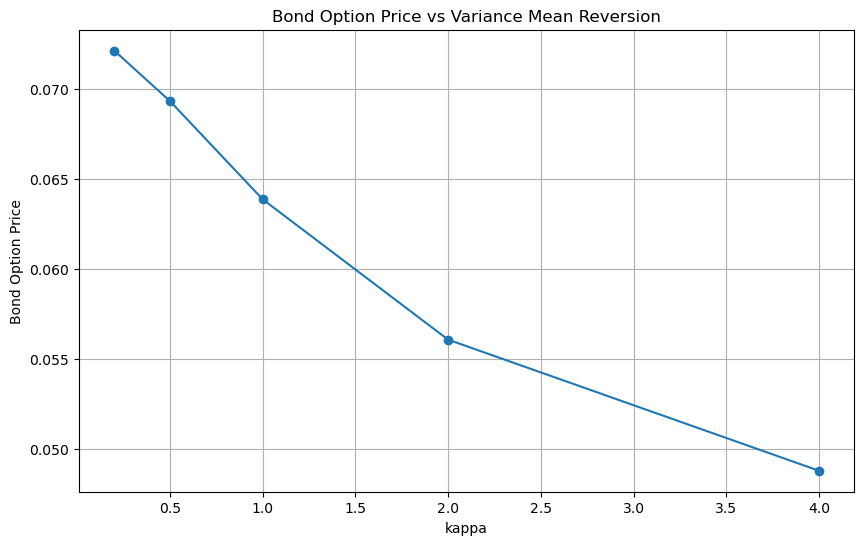

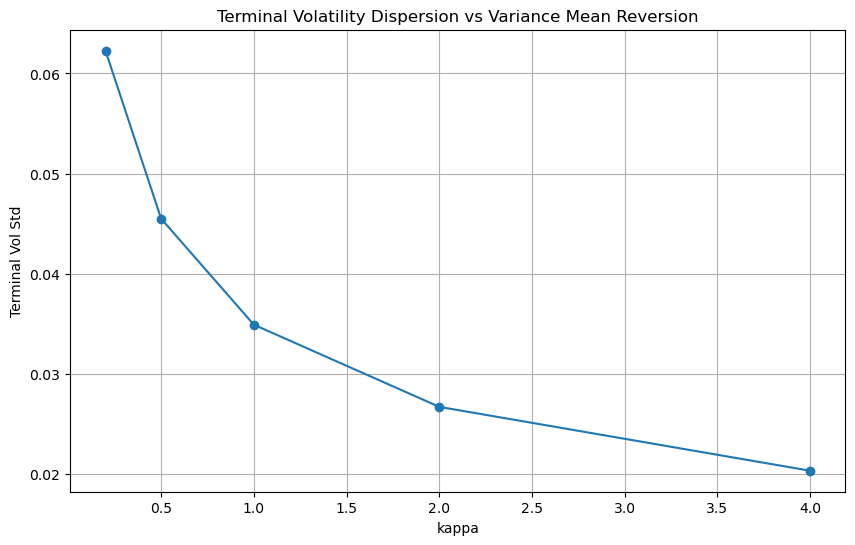

In [37]:
# ============================================================
# Cell — Plot Kappa Scenario Results
# ============================================================

plot_kappa_scenario_summary(
    kappa_df
)

### Interpretation

Higher $\kappa$ pulls variance back toward its long-run level more quickly.

This usually reduces volatility persistence and can reduce the dispersion of future volatility outcomes.

In pricing terms, faster variance mean reversion can reduce the value of volatility-sensitive options.

# 12.4 Scenario Analysis Summary

The scenario analysis highlights three important stochastic-volatility effects:

1. Higher $\eta$ increases volatility uncertainty.
2. $\rho$ changes the relationship between rate moves and volatility moves.
3. Higher $\kappa$ makes volatility shocks less persistent.

Compared with the constant-volatility Hull-White model, the stochastic-volatility extension produces richer and more realistic rate distributions.

This is especially important for:

- callable rates products
- Bermudan swaptions
- XVA exposure simulation
- stress testing
- tail-risk analysis

---

# 13 Summary

Chapter 09 assumed:

$$
\sigma=
constant
$$

which allows analytical pricing formulas.

Chapter 10 introduces:

$$
\sigma_t=
\sqrt{v_t}
$$

which creates a more realistic volatility structure but generally
removes closed-form pricing formulas.

As a result:

- Monte Carlo becomes essential.
- Volatility clustering can emerge.
- Tail risk increases.
- Option prices become more sensitive to volatility assumptions.

The framework presented here is conceptually similar to
Heston-style stochastic-volatility models,
but applied to the short rate rather than an equity asset.

## Practical Note

In this chapter, the Hull-White drift function

$$
\theta(t)
$$

is inherited from the constant-volatility Hull-White model developed in Chapter 09.

Only the diffusion term is replaced by the stochastic variance process:

$$
\sigma
\rightarrow
\sqrt{v_t}.
$$

This simplified construction isolates the effect of stochastic volatility while preserving the original curve-fitting drift.

In production implementations, however, introducing stochastic volatility generally changes the no-arbitrage drift condition. The drift function must therefore be recalibrated numerically to ensure consistency with the observed yield curve.

The implementation presented here should therefore be viewed as a pedagogical stochastic-volatility extension rather than a fully calibrated market model.

## Production Perspective

Modern rates libraries typically use:

- Hull-White
- G2++
- LMM
- SABR
- Stochastic-volatility extensions

for pricing callable bonds, Bermudan swaptions,
structured products and XVA exposures.

The stochastic-volatility short-rate model presented in this chapter
illustrates the key idea:

volatility itself is a state variable and must be simulated together
with the short rate.